# Влияние миграции

Инфекция начинается в первом городе. Для каждой интенсивности измеряются
глобальный пик и первый день появления инфекции во втором и третьем городах.

## Подключение проекта

In [1]:
using DrWatson
@quickactivate "AgentSIRLab"
using DataFrames, Statistics
include(srcdir("experiment_tools.jl"))

summarize_groups (generic function with 1 method)

## Сканирование миграции

In [2]:
rows = NamedTuple[]
for intensity in 0.0:0.1:0.5, seed in 42:44
    model = initialize_sir(Ns=[1000, 1000, 1000], β_und=fill(0.5, 3),
        β_det=fill(0.05, 3), infection_period=14, detection_time=7,
        death_rate=0.02, reinfection_probability=0.1, Is=[3, 0, 0],
        migration_rates=migration_matrix(3, intensity), seed=seed)
    global_rows = [observe(model)]
    city_rows = city_observations(model)
    for _ in 1:150
        advance!(model)
        push!(global_rows, observe(model))
        append!(city_rows, city_observations(model))
    end
    global_frame, city_frame = DataFrame(global_rows), DataFrame(city_rows)
    metrics = epidemic_metrics(global_frame, 3000)
    arrival(city) = begin
        subset = filter(:city => ==(city), city_frame)
        index = findfirst(>(0), subset.infected)
        isnothing(index) ? missing : subset.time[index]
    end
    push!(rows, merge((migration_intensity=intensity, seed=seed,
                       arrival_city_2=arrival(2), arrival_city_3=arrival(3)), metrics))
end
all_runs = save_frame(DataFrame(rows), "sir-migration-effect", "migration-scan-all.csv")
summary = combine(groupby(all_runs, :migration_intensity),
    :peak_day => mean => :mean_peak_day,
    :peak_fraction => mean => :mean_peak_fraction,
    :arrival_city_2 => (x -> mean(skipmissing(x))) => :mean_arrival_city_2,
    :arrival_city_3 => (x -> mean(skipmissing(x))) => :mean_arrival_city_3)
save_frame(summary, "sir-migration-effect", "migration-summary.csv")
best = summary[argmin(summary.mean_peak_day), :]

Row,migration_intensity,mean_peak_day,mean_peak_fraction,mean_arrival_city_2,mean_arrival_city_3
,Float64,Float64,Float64,Float64,Float64
1,0.0,13.0,0.333333,NaN,NaN


## Скорость распространения и пик

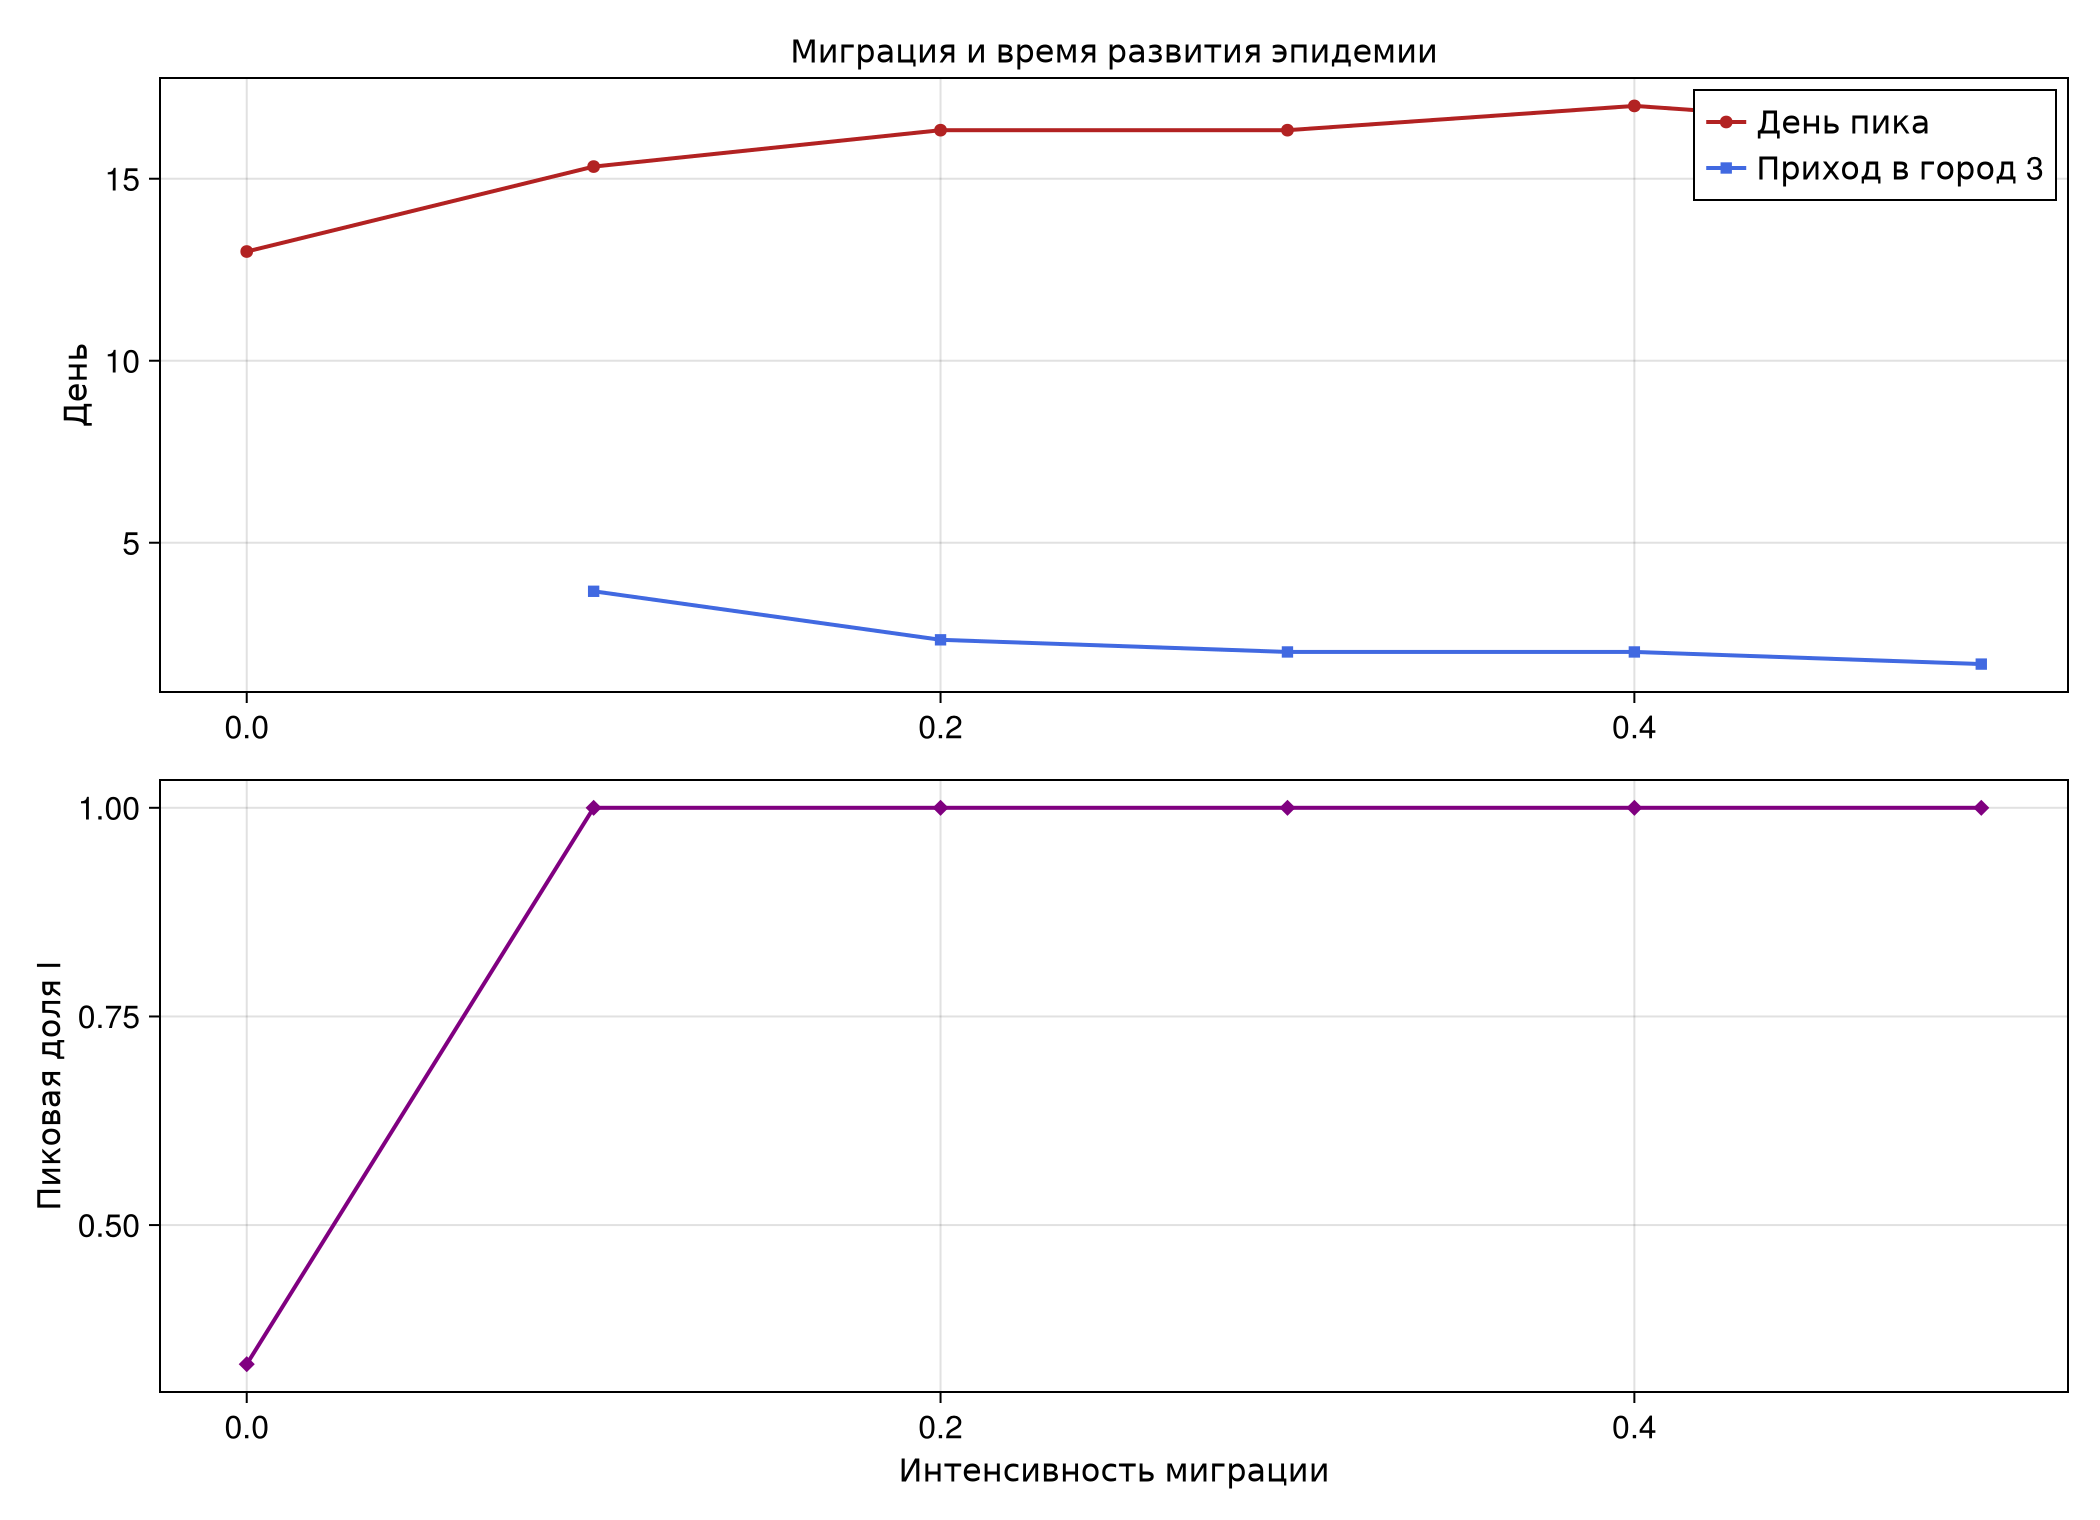

Row,migration_intensity,mean_peak_day,mean_peak_fraction,mean_arrival_city_2,mean_arrival_city_3
,Float64,Float64,Float64,Float64,Float64
1,0.0,13.0,0.333333,NaN,NaN


In [3]:
fig = Figure(size=(1050, 760))
ax1 = Axis(fig[1, 1], title="Миграция и время развития эпидемии", ylabel="День")
scatterlines!(ax1, summary.migration_intensity, summary.mean_peak_day; marker=:circle, label="День пика", color=:firebrick)
scatterlines!(ax1, summary.migration_intensity, summary.mean_arrival_city_3; marker=:rect, label="Приход в город 3", color=:royalblue)
axislegend(ax1; position=:rt)
ax2 = Axis(fig[2, 1], xlabel="Интенсивность миграции", ylabel="Пиковая доля I")
scatterlines!(ax2, summary.migration_intensity, summary.mean_peak_fraction; marker=:diamond, color=:purple)
save_figure(fig, "sir-migration-effect", "migration-effect.png";
            report_name="sir-migration-effect.png")
display(fig)
DataFrame([NamedTuple(best)])